# HOUSE PRICE PREDICTION

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/sample_data/california_housing_train.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
df.shape

(17000, 9)

In [ ]:
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [ ]:
df = pd.read_csv("/content/sample_data/california_housing_train.csv")
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# **EDA (Exploratory Data Analysis)**


# VISUALIZATION

* Distribution of house prices

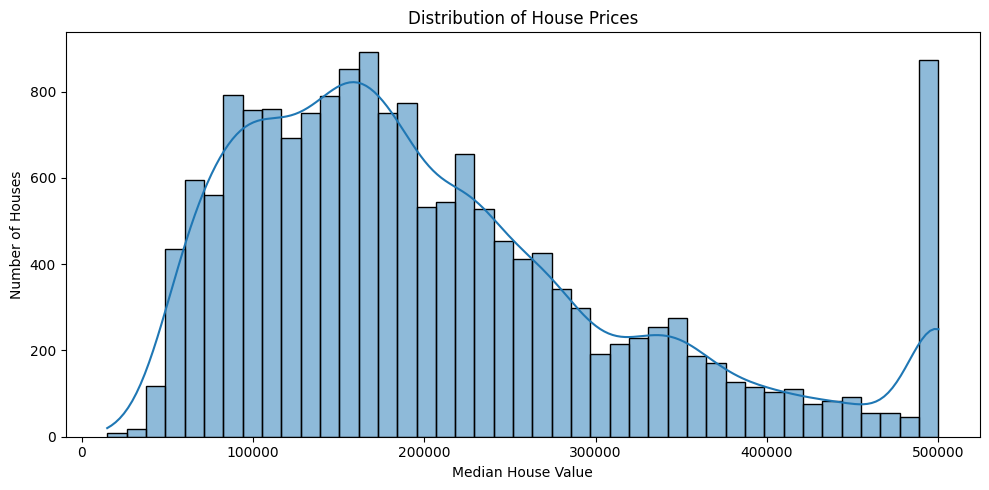

In [ ]:

plt.figure(figsize=(10,5))
sns.histplot(y, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

Observation:
Most house prices are between $50,000 and $250,000.
The distribution is right-skewed.
Fewer houses have prices above $300,000.
There is a large spike at $500,000, indicating the maximum price limit.

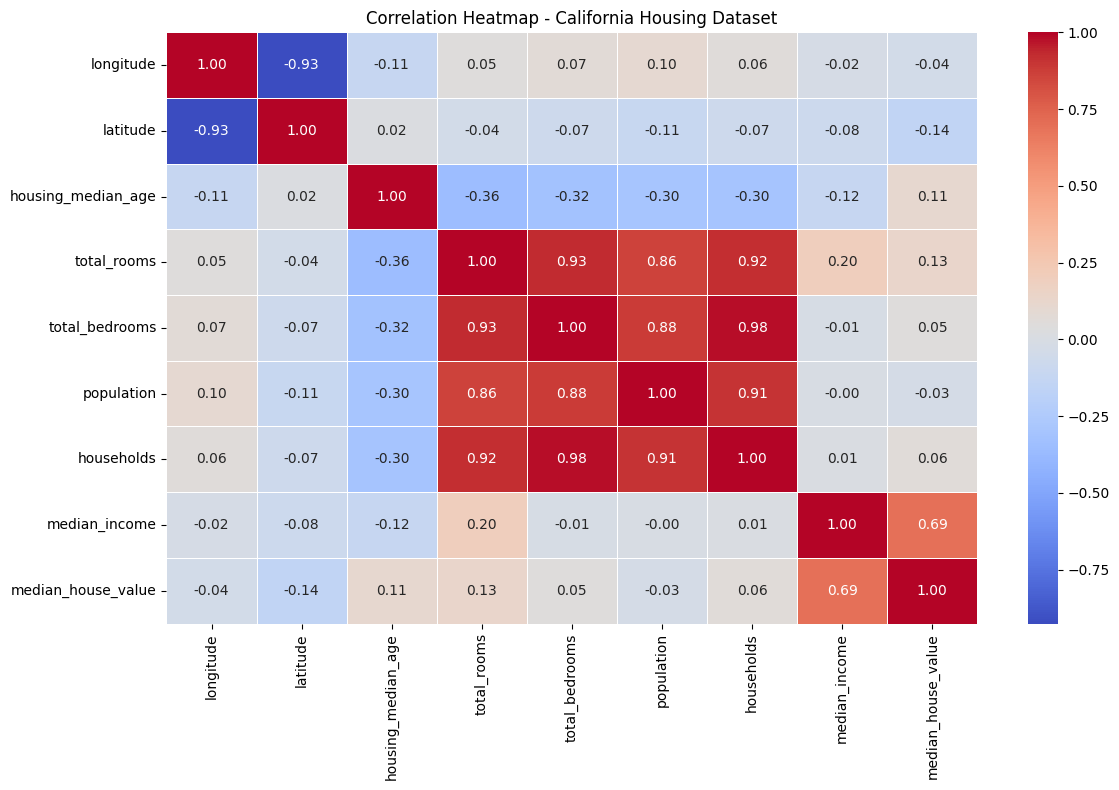

In [19]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap - California Housing Dataset")
plt.tight_layout()
plt.show()

* Living area vs house price

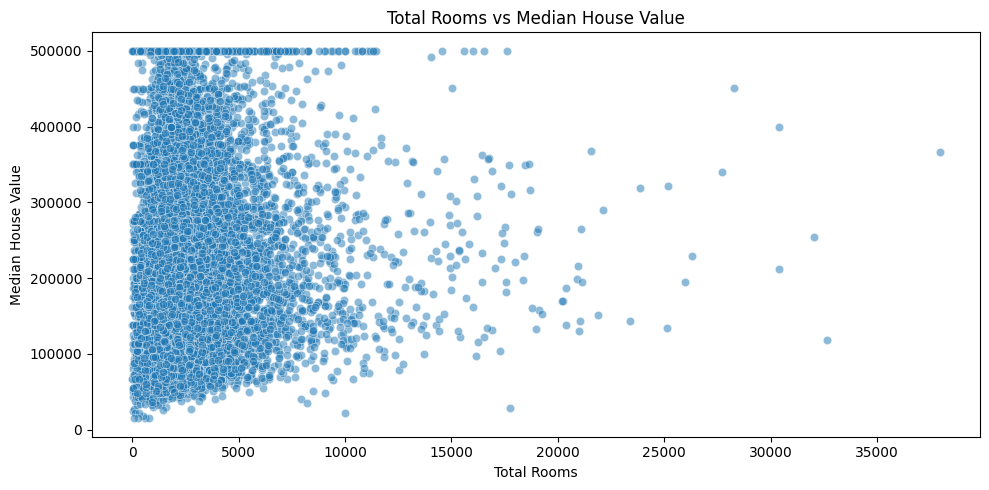

In [ ]:
# Living area vs house price
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x="total_rooms", y="median_house_value", alpha=0.5)
plt.title("Total Rooms vs Median House Value")
plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")
plt.tight_layout()
plt.show()

* Overall quality vs house price

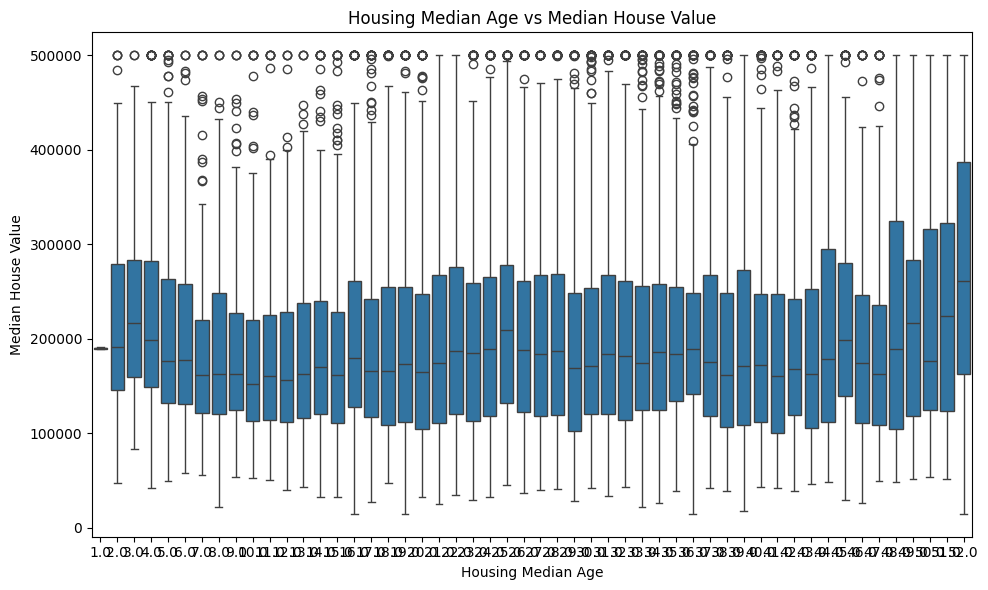

In [ ]:
#Overall quality vs house price
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="housing_median_age", y="median_house_value")
plt.title("Housing Median Age vs Median House Value")
plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")
plt.tight_layout()
plt.show()

# **Feature and Target Selection**

In [48]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]
X = X.fillna(X.median())

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17000, 8)
y shape: (17000,)


#**Split into training and testing data**

In [21]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 13600
Testing rows: 3400


# **FEATURE SCALING**

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# HOUSE PRICE PREDICTION - ALL MODELS

 **1. LINEAR REGRESSION**

In [30]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_pred = linear_model.predict(X_test_scaled)
print("Linear Regression completed!")

Linear Regression completed!


 **2. RANDOM FOREST REGRESSOR**

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest completed!")

Random Forest completed!


 **3. GRADIENT BOOSTING REGRESSOR**

In [32]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(n_estimators=100,learning_rate=0.05,max_depth=3,random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
print("Gradient Boosting completed!")

Gradient Boosting completed!


 **4. ANN - DEEP LEARNING**

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann_model = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

ann_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history = ann_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

ann_pred = ann_model.predict(
    X_test_scaled,
    verbose=0
).flatten()

print("ANN completed!")

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 52984377344.0000 - mae: 199171.8281 - val_loss: 38732513280.0000 - val_mae: 164619.1719
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 20005916672.0000 - mae: 106557.8203 - val_loss: 11470711808.0000 - val_mae: 77114.5859
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10739668992.0000 - mae: 75496.8516 - val_loss: 9033270272.0000 - val_mae: 67848.0312
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8886994944.0000 - mae: 68354.4141 - val_loss: 7598888448.0000 - val_mae: 62057.4688
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7775457280.0000 - mae: 63888.5352 - val_loss: 6597321728.0000 - val_mae: 58604.4531
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6911006208.0000 - mae: 60460.6836 - val_loss: 5986325504.0000 - val_mae: 55675.1250
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6453182464.0000 - mae: 58534.2422 - val_loss: 5546293248.0000 - val_

In [34]:
actual_price = np.expm1(y_test)

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [35]:
linear_price = np.expm1(linear_pred)
rf_price = np.expm1(rf_pred)
gb_price = np.expm1(gb_pred)
ann_price = np.expm1(ann_pred)

/tmp/ipykernel_1038/3270196113.py:1: RuntimeWarning: overflow encountered in expm1
  linear_price = np.expm1(linear_pred)
/tmp/ipykernel_1038/3270196113.py:2: RuntimeWarning: overflow encountered in expm1
  rf_price = np.expm1(rf_pred)
/tmp/ipykernel_1038/3270196113.py:3: RuntimeWarning: overflow encountered in expm1
  gb_price = np.expm1(gb_pred)
/tmp/ipykernel_1038/3270196113.py:4: RuntimeWarning: overflow encountered in expm1
  ann_price = np.expm1(ann_pred)


* Evaluate model

,Model,MAE,RMSE,R2 Score
0,Random Forest Regressor,32359.791500,49414.545905,0.822787
1,Gradient Boosting Regressor,43307.251374,60910.509454,0.730740
2,ANN Deep Learning,44831.432876,63992.715931,0.702800
3,Linear Regression,49983.474651,68078.325525,0.663640


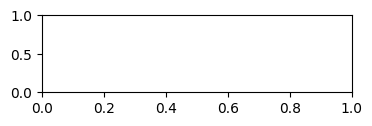

In [38]:
# Evaluate all four models
def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2}

results = [evaluate_model("Linear Regression", y_test, linear_pred),
    evaluate_model("Random Forest Regressor", y_test, rf_pred),
    evaluate_model("Gradient Boosting Regressor", y_test, gb_pred),
    evaluate_model("ANN Deep Learning", y_test, ann_pred)]

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False
      ).reset_index(drop=True)

display(results_df)


#**MAE comparison**

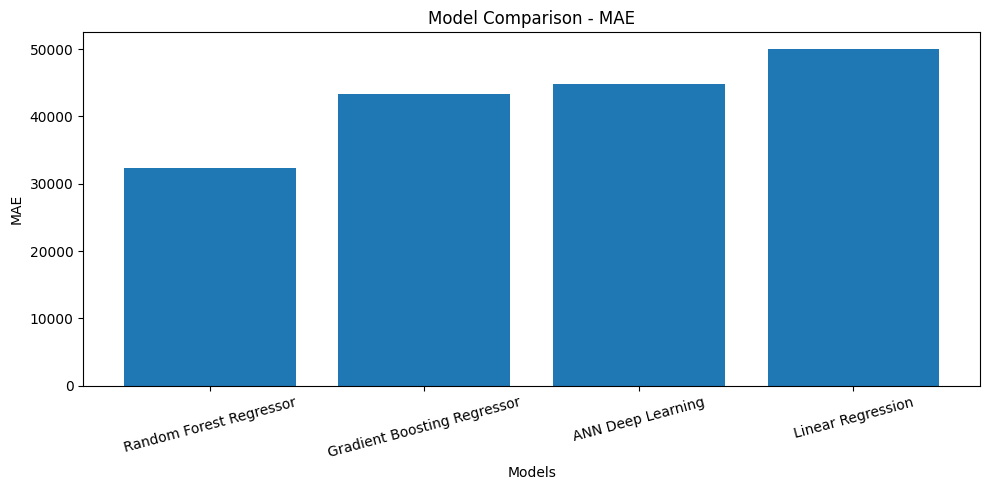

In [39]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison - MAE")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#**RMSE comparison**

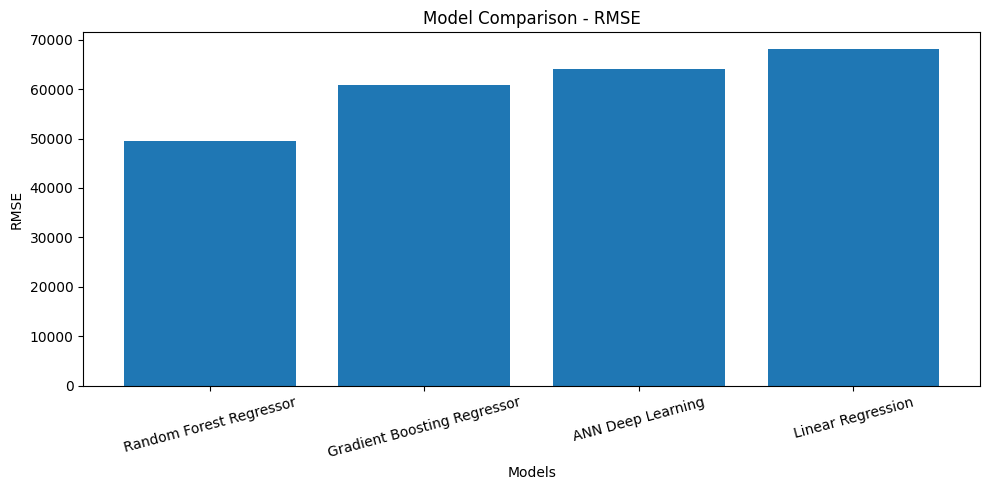

In [40]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison - RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


#**R² Comparison**

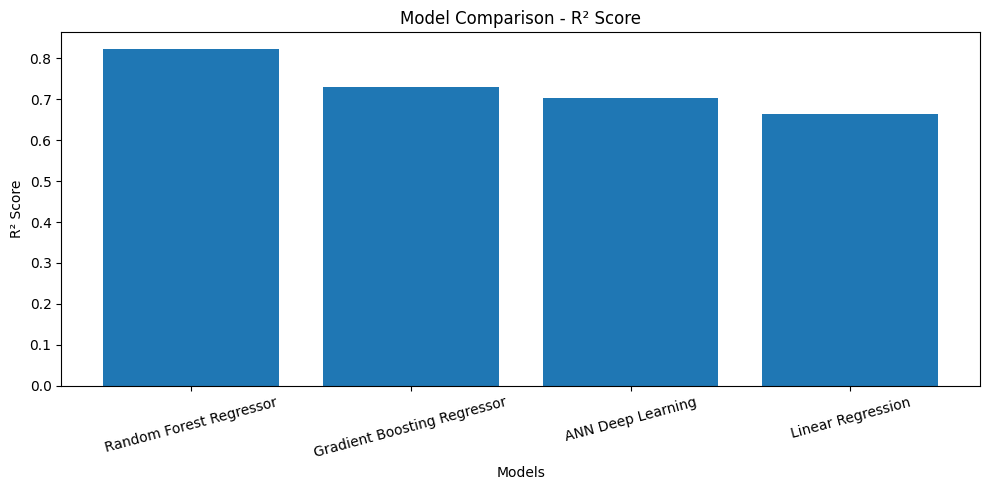

In [43]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("Model Comparison - R² Score")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [44]:
# Best model
best = results_df.iloc[0]
print("Best Model:", best["Model"])
print("MAE:", round(best["MAE"], 2))
print("RMSE:", round(best["RMSE"], 2))
print("R² Score:", round(best["R2 Score"], 4))

Best Model: Random Forest Regressor
MAE: 32359.79
RMSE: 49414.55
R² Score: 0.8228


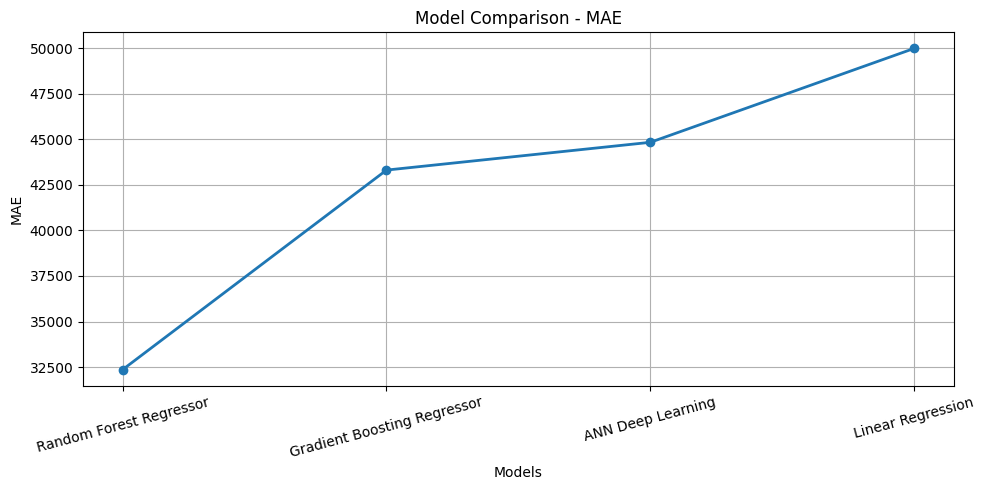

In [54]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["Model"],
    results_df["MAE"],
    marker="o",
    linewidth=2
)

plt.title("Model Comparison - MAE")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.grid(True)
plt.tight_layout()
plt.show()

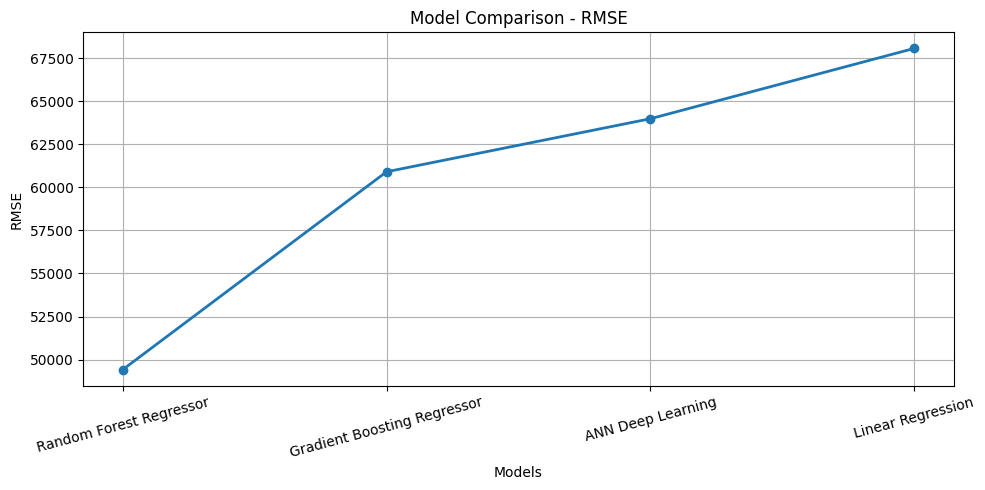

In [52]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["Model"],
    results_df["RMSE"],
    marker="o",
    linewidth=2
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.grid(True)
plt.tight_layout()
plt.show()

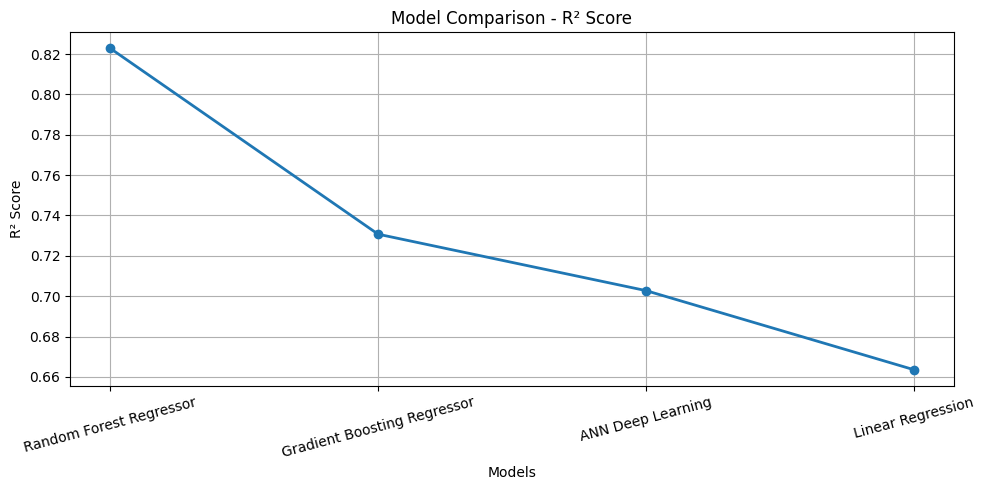

In [53]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["Model"],
    results_df["R2 Score"],
    marker="o",
    linewidth=2
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.grid(True)
plt.tight_layout()
plt.show()

In [55]:
print("Mean Absolute Error (MAE):", best["MAE"])
print("Root Mean Squared Error (RMSE):", best["RMSE"])
print("R2 Score:", best["R2 Score"])

Mean Absolute Error (MAE): 32359.7915
Root Mean Squared Error (RMSE): 49414.54590479251
R2 Score: 0.822786541134775


#Actual vs predicted prices

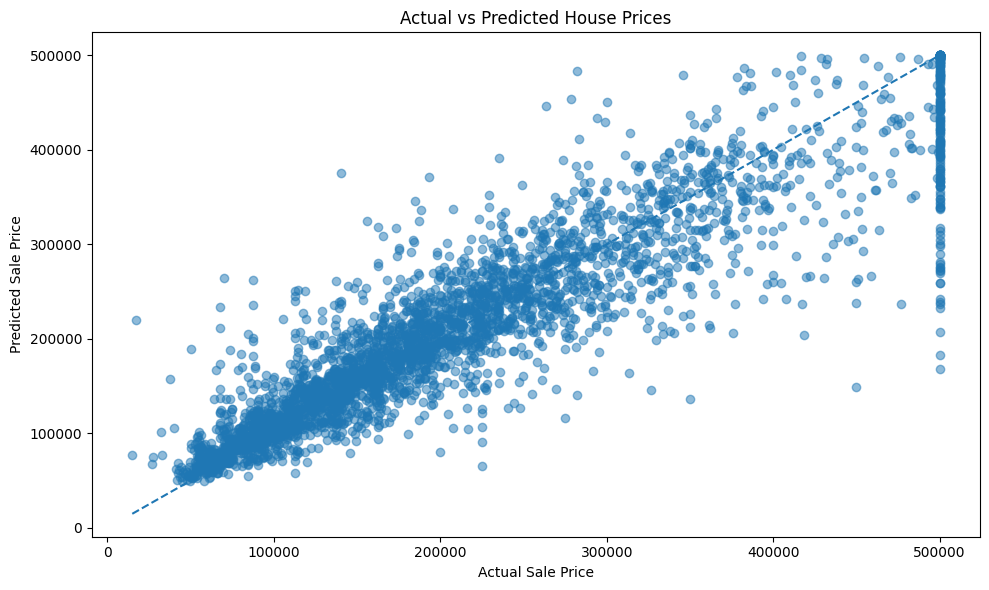

In [60]:
#Actual vs predicted prices

plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_pred, alpha=0.5)

minimum = min(y_test.min(), rf_pred.min())
maximum = max(y_test.max(), rf_pred.max())

plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.tight_layout()
plt.show()

* Prediction error

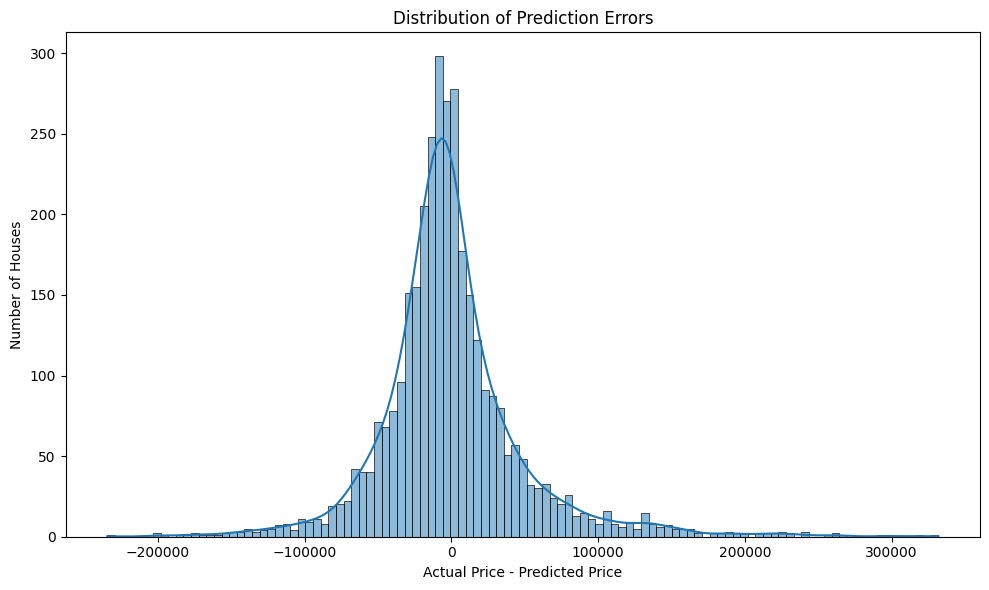

In [59]:
#Prediction error

errors = y_test - rf_pred

plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Actual Price - Predicted Price")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()